# Inverse Probability of Treatment Weighting (IPTW)

`IPTWWeighter` is a propensity-score-based weighter: rather than selecting a subset of the pool
(as the genetic/LP/propensity matchers elsewhere in `pybalance` do), it **reweights every pool
patient**. It:

1. fits a propensity model $p(X) = P(\mathrm{target} \mid X)$ that classifies pool vs. target
   patients on their covariates (`sklearn.linear_model.LogisticRegression` by default), then
2. weights each pool patient by the odds $p / (1 - p)$.

The target population keeps weight 1, so this is the **ATT estimand**, with the target playing the
role of the fixed/reference ("treated") group -- the natural fit for this package's typical use
case of reweighting a real-world data (RWD) pool to represent a trial population.

IPTW:
- **requires a patient-level target** (there's no pool-vs-target classification problem to fit
  against a published, aggregate-only Table 1);
- **does not guarantee exact balance** on any particular moment -- only asymptotically, and only
  if the propensity model is well specified;
- is nonetheless the most widely used and reported method for this kind of reweighting in the
  observational literature (Rosenbaum & Rubin, 1983; Austin, 2011).


In [1]:
import logging

import matplotlib.pyplot as plt

from pybalance.sim import generate_toy_dataset
from pybalance.utils import MatchingData, MatchingHeaders
from pybalance.visualization import plot_categoric_features, plot_numeric_features
from pybalance.weighting import (
    IPTWWeighter,
    plot_iptw_propensity_distributions,
    weighted_balance_table,
)

%matplotlib inline

# show effective-sample-size / trimming diagnostics logged during fit()
logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)

## Synthetic data: two genuinely different, patient-level populations

IPTW needs patient-level covariates on *both* sides so it can fit a pool-vs-target classifier. We
use `generate_toy_dataset`'s pool and target populations directly, with no aggregation step.

In [2]:
m = generate_toy_dataset(n_pool=2000, n_target=300, seed=11)
pool_df = m.get_population("pool").drop(columns=[m.population_col])
target_df = m.get_population("target").drop(columns=[m.population_col])

headers = MatchingHeaders(numeric=["age", "weight", "height"], categoric=["gender", "haircolor"])
matching_data = MatchingData(pool=pool_df, target=target_df, headers=headers)
matching_data.describe()

pool      target
population size N       2000.0000  300.000000
gender          0.0        0.4830    0.553333
                1.0        0.5170    0.446667
haircolor       0.0        0.3935    0.176667
                1.0        0.3045    0.403333
                2          0.3020    0.420000
age             mean      55.4200   46.710000
                std       13.1500   13.720000
                min       18.2700   18.720000
                q25       46.6200   36.290000
                median    57.4700   47.410000
                q75       66.1700   55.930000
                max       74.9900   74.600000
weight          mean      88.7000   82.100000
                std       16.4400   19.110000
                min       50.2200   50.160000
                q25       76.7700   65.520000
                median    89.4800   81.130000
                q75      101.1000   96.190000
                max      119.9500  119.660000
height          mean     159.0500  155.180000
                std       19.5900   17.190000
                min      125.0400  125.160000
                q25      142.1000  140.920000
                median   158.7400  154.890000
                q75      175.3700  167.800000
                max      194.9500  194.230000

## Fit `IPTWWeighter`

As with the other weighters, `match()` fits (if needed) and returns a `MatchingData` with every
pool patient retained, plus a new `sample_weight` column. `weighted_balance_table()` compares
each feature's target moment to the unweighted and weighted pool moment -- but, unlike an
exact-balance weighter, don't expect the "weighted" column to land exactly on target.

In [3]:
weighter = IPTWWeighter(matching_data, verbose=True)
matched = weighter.match()

weighted_balance_table(weighter)

IPTWWeighter fit LogisticRegression. Effective sample size: 946.5 / 2000 pool patients.


,feature,moment,target,unweighted_pool,weighted_pool
0,gender_1.0,mean,0.446667,0.517000,0.498286
1,haircolor_1,mean,0.403333,0.304500,0.403873
2,haircolor_2,mean,0.420000,0.302000,0.414048
3,age,mean,46.705231,55.417328,47.326641
4,weight,mean,82.095245,88.704041,82.229043
5,height,mean,155.177505,159.050598,153.852687


In [4]:
print(f"Effective sample size: {weighter.effective_sample_size():.1f} / {len(pool_df)} pool patients")
print(f"Propensity model: {weighter.propensity_model}")
matched.get_population(matched.pool_name)["sample_weight"].describe()

Effective sample size: 946.5 / 2000 pool patients
Propensity model: LogisticRegression(max_iter=1000)


count    2000.000000
mean        0.146556
std         0.154660
min         0.006937
25%         0.052532
50%         0.094784
75%         0.184358
max         1.642370
Name: sample_weight, dtype: float64

## Checking overlap: propensity score and weight distributions

IPTW relies on **positivity**: every pool patient needs a realistic chance of looking like the
target on the fitted model. A propensity score distribution piled up near 0 or 1, or a handful of
huge weights, is the practical warning sign -- the reweighting is leaning hard on a small,
possibly unrepresentative slice of the pool (the same concern `effective_sample_size()` summarizes
in one number).

`plot_iptw_propensity_distributions()` is the weighting counterpart to
`pybalance.propensity.plot_propensity_score_match_distributions()`: instead of a matched subset's
"before" vs. "after" panels, it shows the same pool/target propensity scores counted equally
("before") vs. counted by the fitted IPTW weight ("after") -- the weighted pool histogram should
move towards the target's.

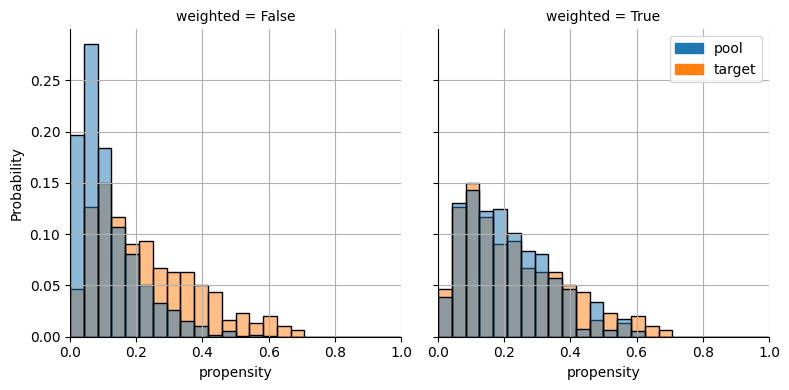

In [5]:
plot_iptw_propensity_distributions(weighter);

Both `plot_numeric_features` and `plot_categoric_features` accept a `weights=` column, so the
unweighted pool (every patient counted equally) and the IPTW-weighted pool can be plotted
side by side against the same target, to see what the reweighting actually bought.

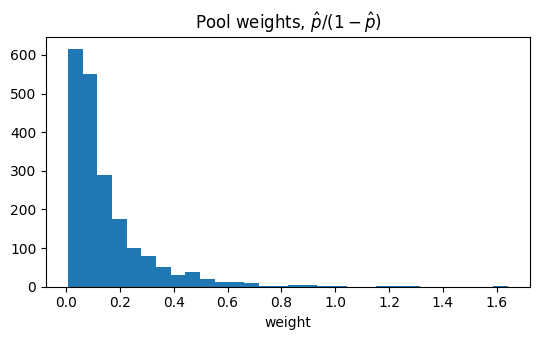

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.hist(weighter.weights, bins=30)
ax.set_title(r"Pool weights, $\hat{p} / (1 - \hat{p})$")
ax.set_xlabel("weight")
fig.tight_layout()

To see the effect on the covariates themselves (rather than the propensity score), put the
unweighted pool, the IPTW-weighted pool and the target into a single `MatchingData` -- the same
trick the matching demos use to show "pool (prematch)" alongside "pool" and "target" in one plot --
and pass `weights=` through to `plot_numeric_features`/`plot_categoric_features`. The unweighted
pool copy gets weight 1, so a single call draws all three distributions together instead of two
separate before/after figures.

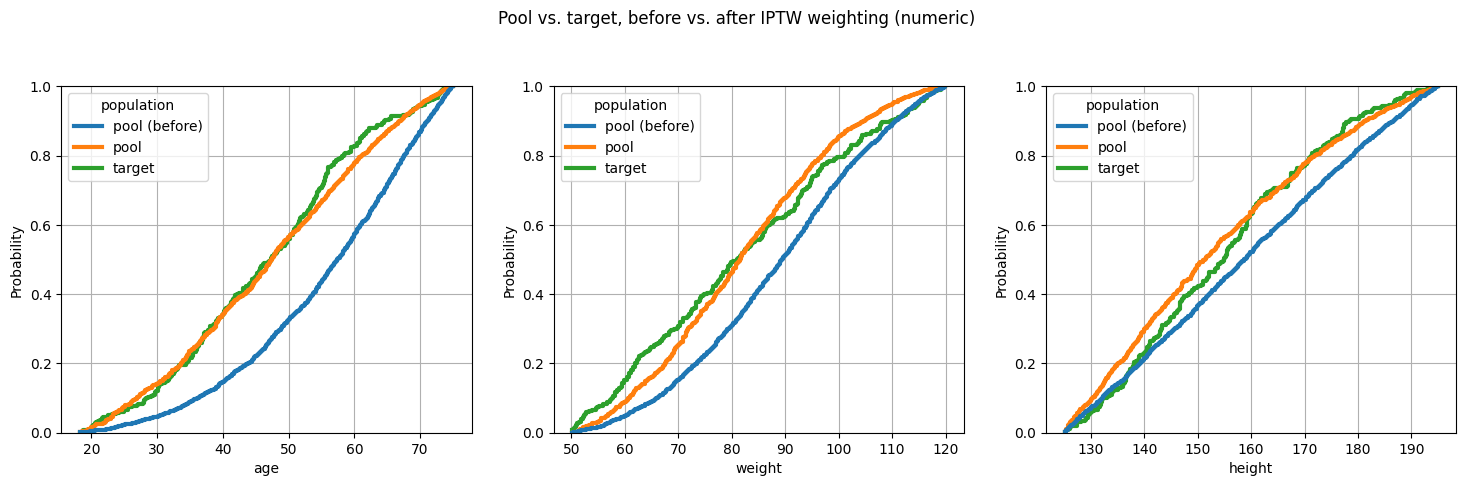

In [7]:
before_pool = matching_data.get_population(matching_data.pool_name).copy()
before_pool[weighter.weight_col] = 1.0

combined = matched.copy()
combined.append(before_pool, name="pool (before)")
hue_order = ["pool (before)", matching_data.pool_name, matching_data.target_name]

plot_numeric_features(
    combined, weights=weighter.weight_col, hue_order=hue_order, include_only=headers.numeric, col_wrap=3
)
plt.suptitle("Pool vs. target, before vs. after IPTW weighting (numeric)", y=1.05);

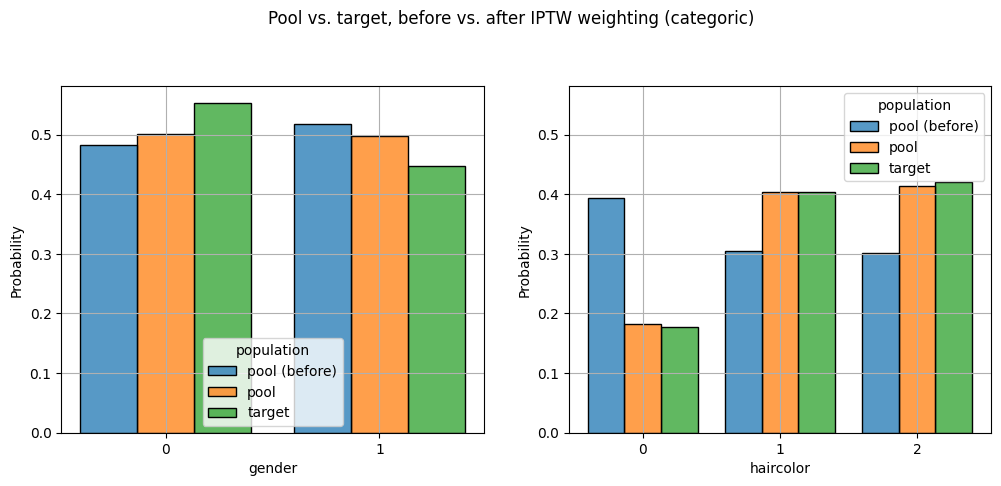

In [8]:
plot_categoric_features(
    combined, weights=weighter.weight_col, hue_order=hue_order, include_only=headers.categoric, col_wrap=2
)
plt.suptitle("Pool vs. target, before vs. after IPTW weighting (categoric)", y=1.05);

## Trimming extreme weights

The main practical failure mode of IPTW is a small number of extreme weights, driven by pool
patients whose covariates make the model almost certain they're pool (weight -> 0) or almost
certain they're target (weight -> large). `trim_quantiles=(low, high)` clips fitted weights at the
given quantiles -- a standard bias/variance trade-off: a little exact balance is sacrificed in
exchange for a much more stable, lower-variance set of weights.

IPTWWeighter fit LogisticRegression. Effective sample size: 1148.0 / 2000 pool patients. Trimmed 200 extreme weights.


Untrimmed: ESS=946.5, max weight=1.64
Trimmed:   ESS=1148.0, max weight=0.46, n_trimmed=200


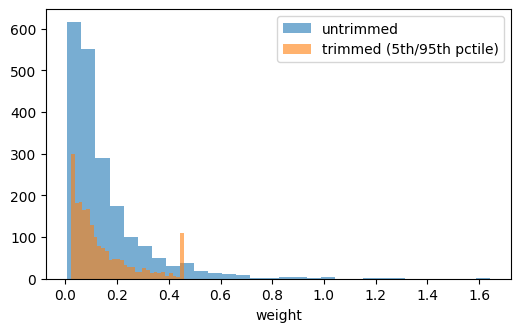

In [9]:
trimmed = IPTWWeighter(matching_data, trim_quantiles=(0.05, 0.95), verbose=True)
trimmed.match()

print(f"Untrimmed: ESS={weighter.effective_sample_size():.1f}, max weight={weighter.weights.max():.2f}")
print(f"Trimmed:   ESS={trimmed.effective_sample_size():.1f}, max weight={trimmed.weights.max():.2f}, n_trimmed={trimmed.diagnostics['n_trimmed']}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(weighter.weights, bins=30, alpha=0.6, label="untrimmed")
ax.hist(trimmed.weights, bins=30, alpha=0.6, label="trimmed (5th/95th pctile)")
ax.set_xlabel("weight")
ax.legend();

## Takeaways

- `IPTWWeighter` fits a pool-vs-target propensity model and weights the pool by $\hat p / (1 -
  \hat p)$; the target keeps weight 1 (the ATT estimand, target-as-reference).
- It requires a **patient-level** target -- there's no aggregate-only ("published Table 1")
  variant.
- It does **not** solve for exact balance, so always check `weighted_balance_table()` and
  `effective_sample_size()` on the fitted result, the same as for any other weighter.
- `trim_quantiles` caps extreme weights, trading a little bias for a large reduction in variance --
  worth reaching for whenever a handful of patients end up dominating the effective sample size.